### Graph relationships

In [1]:
import pandas as pd 
df = pd.read_csv("Animal_Dataset.csv") #loads in csv file into dataframe 

Possible graphable relationships:

-avg speed: 94 unique
-top speed: 70 unique
-weight: 176 unique
-height: 154 unique
-lifespan: 90 
-gestation period: 156
-offspring per birth: 66
-diet: 16
-social structure: 10
-conservation status: 9

-Edits done


### Cleaning

#### Height

In [2]:
column_name = "Height (cm)"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

Up to 30: 4
70-90: 4
Up to 60: 4
200-250: 3
Up to 150: 3
Up to 15: 3
50-60: 3
Up to 160: 3
Up to 120: 2
200-300: 2
25-35: 2
120-200: 2
Up to 300: 2
Varies: 2
Up to 35: 2
Up to 90: 2
Up to 550: 2
30-45: 2
Up to 20: 2
70-120: 2
Up to 180: 2
Up to 5: 2
25-30: 2
Up to 75: 2
40-50: 2
140-160: 2
45-75: 2
Up to 9: 2
140-200: 2
41-71: 1
76-107: 1
70-102: 1
112-160: 1
35-37: 1
105-130: 1
270-310: 1
75-80: 1
80-110: 1
67-101: 1
2-13: 1
152-186: 1
52-91: 1
90-110: 1
35-40: 1
Up to 1100: 1
20-36: 1
Up to 460: 1
50-62: 1
48-58: 1
Up to 200: 1
140-188: 1
Up to 270: 1
100: 1
7-10: 1
50-61: 1
50-55: 1
96-150: 1
81-85: 1
Up to 40: 1
15-25: 1
20-40: 1
14-30: 1
23-26: 1
180-300: 1
48-53: 1
80-105: 1
2.2-7.7: 1
Up to 600: 1
3-6: 1
Up to 320: 1
Up to 670: 1
130-160: 1
Up to 127: 1
Up to 183: 1
86-107: 1
120-160: 1
7.5-13: 1
Up to 56: 1
Up to 1700: 1
60-70: 1
Up to 70: 1
35-55: 1
7-15: 1
25-46: 1
Up to 25: 1
Up to 3350: 1
200-400: 1
53-63: 1
22-30: 1
132-180: 1
67-107: 1
300-400: 1
80-100: 1
45-60: 1
30-50:

In [3]:
def find_invalid_height_formats(df, column_name):
    invalid_values = []

    for value in df[column_name].dropna().unique():
        value_str = str(value).strip()

        # Check if it contains "Up to" OR "-"
        if not ("Up to" in value_str or "-" in value_str):
            invalid_values.append(value_str)

    # Print results
    print("Invalid height formats:")
    for v in invalid_values:
        print(v)

    print("\nTotal invalid values:", len(invalid_values))

    return invalid_values

col = "Height (cm)"
print(find_invalid_height_formats(df, col))

Invalid height formats:
100
Varies

Total invalid values: 2
['100', 'Varies']


In [4]:
#Get all speed values
import pandas as pd
import re

def extract_numeric_heights(df, column_name):
    heights = []
    bad_count = 0
    for value in df[column_name].dropna():
        val = str(value).strip()

        # Skip "Varies"
        if val.lower() == "varies":
            bad_count +=1
            continue

        # Extract all numbers (handles decimals too)
        numbers = re.findall(r"\d+\.?\d*", val)

        if not numbers:
            bad_count +=1
            continue  # skip anything weird

        numbers = [float(n) for n in numbers]

        # Case 1: range (A-B)
        if "-" in val and len(numbers) >= 2:
            avg = sum(numbers[:2]) / 2
            heights.append(avg)

        # Case 2: "Up to X"
        elif "up to" in val.lower():
            heights.append(numbers[0])
            
        # Case 3: single number
        else:
            heights.append(numbers[0])

    print(bad_count)

    return heights

height_list = extract_numeric_heights(df, "Height (cm)")

print(height_list)  
print("Total cleaned values:", len(height_list))



2
[117.5, 45.0, 290.0, 95.0, 77.5, 84.0, 7.5, 169.0, 71.5, 150.0, 80.0, 27.5, 120.0, 250.0, 27.5, 225.0, 136.0, 30.0, 36.0, 91.5, 86.0, 56.0, 75.0, 1100.0, 60.0, 37.5, 100.0, 156.0, 30.0, 26.0, 15.0, 3350.0, 83.0, 20.0, 150.0, 123.0, 300.0, 58.0, 5.0, 95.0, 460.0, 56.0, 80.0, 160.0, 180.0, 8.5, 200.0, 225.0, 28.0, 45.0, 55.5, 52.5, 53.0, 300.0, 164.0, 37.5, 270.0, 100.0, 24.5, 22.0, 30.0, 20.0, 40.0, 80.0, 90.0, 50.5, 183.0, 240.0, 92.5, 600.0, 5.0, 80.0, 60.0, 4.95, 320.0, 35.0, 4.5, 670.0, 550.0, 120.0, 145.0, 127.0, 180.0, 96.5, 140.0, 56.0, 10.25, 1700.0, 65.0, 70.0, 45.0, 55.0, 60.0, 11.0, 550.0, 35.5, 300.0, 25.0, 35.0, 40.0, 52.5, 90.0, 150.0, 350.0, 75.0, 87.0, 30.0, 115.0, 30.0, 244.0, 160.0, 9.0, 500.0, 30.0, 40.0, 225.0, 160.0, 65.0, 60.0, 18.0, 13.5, 12.5, 160.0, 39.5, 15.0, 60.0, 92.5, 60.0, 47.0, 42.5, 160.0, 57.5, 6.3, 62.5, 90.0, 125.0, 58.0, 125.0, 394.0, 55.0, 55.0, 29.0, 60.0, 61.5, 160.0, 2056.0, 49.5, 81.0, 30.0, 16.0, 83.0, 128.5, 78.5, 135.0, 95.0, 16.0, 53.0, 11

In [5]:
def bin_heights(height_list):
    # Create bins
    bins = [(i, i+20) for i in range(0, 200, 20)]
    
    # Initialize counts
    bin_counts = {f"{low}-{high}": 0 for low, high in bins}
    bin_counts["200+"] = 0

    # Assign values to bins
    for h in height_list:
        placed = False

        for low, high in bins:
            if low <= h < high:
                bin_counts[f"{low}-{high}"] += 1
                placed = True
                break

        # If not placed, goes to 200+
        if not placed:
            bin_counts["200+"] += 1

    # Print results
    for bin_range, count in bin_counts.items():
        print(f"{bin_range}: {count}")

    return bin_counts

height_bin = bin_heights(height_list)

0-20: 22
20-40: 27
40-60: 26
60-80: 22
80-100: 22
100-120: 7
120-140: 10
140-160: 8
160-180: 10
180-200: 3
200+: 35


#### Weight

In [6]:
column_name = "Weight (kg)"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

Up to 0.5: 4
3-6: 3
Up to 90: 3
Up to 55: 3
150-400: 2
Up to 1500: 2
Up to 2.3: 2
30-82: 2
Up to 6: 2
Up to 0.1: 2
Varies: 2
Up to 0.03: 2
Up to 0.7: 2
40-65: 1
2700-6000: 1
8-14: 1
120-140: 1
500-620: 1
2000-5000: 1
Up to 6.7: 1
2.2-2.7: 1
2-5: 1
Up to 300: 1
18-40: 1
Up to 600: 1
2.5-4: 1
220-260: 1
800-1,400: 1
Up to 10: 1
0.07-0.12: 1
5-13: 1
400-700: 1
Up to 200000 : 1
Up to 0.028: 1
Up to 0.3: 1
1.5-3: 1
150-650: 1
25-32: 1
Up to 0.006: 1
30-40: 1
22-41: 1
380-1000: 1
65-90: 1
2.5-9: 1
120-250: 1
18-36: 1
19-120: 1
318-1000: 1
4.5-16: 1
100-135: 1
50-300: 1
Up to 65: 1
26-70: 1
20-72: 1
35-66: 1
70-780: 1
22-45: 1
300-400: 1
0.6-1.2: 1
12-21: 1
73-204: 1
2.5-6.5: 1
13-20: 1
23-32: 1
Up to 417: 1
1.7-2.6: 1
5-8: 1
Up to 1.1: 1
0.8-1.6: 1
28-52: 1
70-125: 1
600-1300: 1
Up to 25: 1
Up to 210: 1
Up to 2.4: 1
Up to 2268: 1
Up to 97.5: 1
Up to 200: 1
Up to 20: 1
Up to 420: 1
Up to 160: 1
350-450: 1
2-20: 1
4.5-9: 1
Up to 30000: 1
9-14: 1
10-14: 1
1300-3200: 1
0.035-0.15: 1
Up to 9: 1
1

In [7]:
def find_invalid_weight_formats(df, column_name):
    invalid_values = []

    for value in df[column_name].dropna().unique():
        value_str = str(value).strip()

        # Check if it contains "Up to" OR "-"
        if not ("Up to" in value_str or "-" in value_str):
            invalid_values.append(value_str)

    # Print results
    print("Invalid weight formats:")
    for v in invalid_values:
        print(v)

    print("\nTotal invalid values:", len(invalid_values))

    return invalid_values

col = "Weight (kg)"
print(find_invalid_weight_formats(df, col))

Invalid weight formats:
Varies

Total invalid values: 1
['Varies']


In [8]:
import re

def extract_numeric_weights(df, column_name):
    weights = []
    bad_count = 0

    for value in df[column_name].dropna():
        val = str(value).strip()

        # Skip "Varies"
        if val.lower() == "varies":
            bad_count += 1
            continue

        # Remove commas (e.g., "1,400" → "1400")
        val = val.replace(",", "")

        # Extract all numbers (handles decimals)
        numbers = re.findall(r"\d+\.?\d*", val)

        if not numbers:
            bad_count += 1
            continue

        numbers = [float(n) for n in numbers]

        # Case 1: range (A-B)
        if "-" in val and len(numbers) >= 2:
            avg = (numbers[0] + numbers[1]) / 2
            weights.append(avg)

        # Case 2: "Up to X"
        elif "up to" in val.lower():
            weights.append(numbers[0])

        # Case 3: single number
        elif len(numbers) == 1:
            weights.append(numbers[0])

        else:
            bad_count += 1

    return weights, bad_count

weight_list, bad_count = extract_numeric_weights(df, "Weight (kg)")

print("Weight list", weight_list)
print("Total clean weights:", len(weight_list))
print("Bad/removed entries:", bad_count)



Weight list [52.5, 11.0, 4350.0, 185.0, 27.0, 69.5, 0.5, 659.0, 31.5, 690.0, 77.5, 5.75, 6.7, 3500.0, 560.0, 130.0, 29.0, 300.0, 2.45, 275.0, 4.5, 3.5, 9.0, 550.0, 600.0, 3.25, 240.0, 1100.0, 10.0, 0.095, 0.028, 200000.0, 2.25, 0.3, 35.0, 56.0, 400.0, 28.5, 0.006, 425.0, 90.0, 50.5, 46.0, 48.0, 65.0, 175.0, 90.0, 117.5, 10.25, 4.5, 27.5, 16.5, 16.5, 420.0, 138.5, 4.5, 20.0, 33.5, 350.0, 0.8999999999999999, 1.2000000000000002, 55.0, 1.1, 6.5, 0.5, 2.15, 417.0, 950.0, 40.0, 1500.0, 25.0, 97.5, 2.3, 0.03, 210.0, 0.7, 2.4, 2268.0, 97.5, 200.0, 400.0, 0.7, 160.0, 6.75, 2250.0, 2.3, 11.0, 30000.0, 11.5, 6.0, 6.0, 12.0, 4.0, 0.0925, 9.0, 2.15, 90.0, 250.0, 0.5, 2.05, 6.25, 1.05, 2.2, 495.0, 55.0, 22.5, 2.7, 110.0, 0.8, 166.0, 135.0, 80.0, 1600.0, 1.0, 0.66, 275.0, 56.0, 21.0, 10.75, 0.4, 0.1, 1.5499999999999998, 700.0, 0.6, 0.26, 19.0, 55.0, 0.8, 3.75, 5.0, 56.5, 4.5, 0.1, 48.0, 100.0, 3.4, 13.0, 5.0, 800.0, 21.5, 6.3, 0.9500000000000001, 48.5, 2.45, 56.0, 57000.0, 7.5, 54.0, 0.75, 0.06, 39.5

In [9]:
def weight_bins(weight_list):
    # Create bins: 0–20, 20–40, ..., 180–200
    bins = [(i, i+20) for i in range(0, 200, 20)]
    
    # Initialize counts
    bin_counts = {f"{low}-{high}": 0 for low, high in bins}
    bin_counts["200+"] = 0

    # Assign weights to bins
    for w in weight_list:
        placed = False

        for low, high in bins:
            if low <= w < high:
                bin_counts[f"{low}-{high}"] += 1
                placed = True
                break

        # If not placed → 200+
        if not placed:
            bin_counts["200+"] += 1

    # Print results
    for bin_range, count in bin_counts.items():
        print(f"{bin_range}: {count}")

    return bin_counts

weight_bins = weight_bins(weight_list)
print(weight_bins)

0-20: 86
20-40: 16
40-60: 18
60-80: 5
80-100: 8
100-120: 4
120-140: 5
140-160: 0
160-180: 3
180-200: 1
200+: 46
{'0-20': 86, '20-40': 16, '40-60': 18, '60-80': 5, '80-100': 8, '100-120': 4, '120-140': 5, '140-160': 0, '160-180': 3, '180-200': 1, '200+': 46}


#### Lifespan

In [10]:
column_name = "Lifespan (years)"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

10-15: 21
15-20: 11
20-25: 10
20-30: 10
Up to 20: 8
25-30: 6
Varies: 6
10-12: 6
40-50: 5
5-10: 3
3-5: 3
8-10: 3
40-60: 3
10-13: 3
10-20: 3
10-14: 3
6-8: 2
Up to 100: 2
3-6: 2
6-15: 2
10-17: 2
Up to 10: 2
15-18: 2
30-35: 2
10-25: 2
30-40: 2
8-12: 2
Up to 5: 2
35-40: 2
50-60: 2
12-14: 2
2-5: 2
30-50: 2
6-10: 2
60-70: 1
4-17: 1
60-80: 1
14-17: 1
7-10: 1
Up to 30: 1
0.5-0.7: 1
12-17: 1
70-90: 1
0.4: 1
35-50: 1
20-23: 1
80-100: 1
70: 1
100-150: 1
15-23: 1
70-80: 1
Up to 60: 1
1-2: 1
20-50: 1
Up to 70: 1
35-45: 1
20-40: 1
15-25: 1
25-50: 1
60: 1
25-35: 1
45-50: 1
20-35: 1
Up to 300: 1
4: 1
6-12: 1
3-10: 1
Up to 15: 1
Up to 23: 1
Up to 21: 1
30-45: 1
Up to 32: 1
10-16: 1
28-35: 1
25-36: 1
20-24: 1
Up to 4: 1
12-20: 1
5-8: 1
12-25: 1
4-7: 1
5-20: 1
Up to 28: 1
10: 1
20-21: 1
70-100: 1
8-13: 1
7-12: 1

Total unique values: 88


In [11]:
def find_invalid_lifespan_formats(df, column_name):
    invalid_values = []

    for value in df[column_name].dropna().unique():
        value_str = str(value).strip()

        # Check if it contains "Up to" OR "-"
        if not ("Up to" in value_str or "-" in value_str):
            invalid_values.append(value_str)

    # Print results
    print("Invalid lifespan formats:")
    for v in invalid_values:
        print(v)

    print("\nTotal invalid values:", len(invalid_values))

    return invalid_values

col = "Lifespan (years)"
print(find_invalid_lifespan_formats(df, col))

Invalid lifespan formats:
0.4
Varies
70
60
4
10

Total invalid values: 6
['0.4', 'Varies', '70', '60', '4', '10']


In [12]:
import re

def extract_lifespan_values(df, column_name):
    lifespans = []
    bad_count = 0

    for value in df[column_name].dropna():
        val = str(value).strip().lower()

        # Skip "Varies"
        if val == "varies":
            bad_count += 1
            continue

        # Handle "60+" → treat as 60
        if "+" in val:
            numbers = re.findall(r"\d+\.?\d*", val)
            if numbers:
                lifespans.append(float(numbers[0]))
            else:
                bad_count += 1
            continue

        # Remove words like "days", "years"
        val = re.sub(r"[a-zA-Z]+", "", val).strip()

        # Extract numbers
        numbers = re.findall(r"\d+\.?\d*", val)

        if not numbers:
            bad_count += 1
            continue

        numbers = [float(n) for n in numbers]

        # Case 1: range (A-B)
        if "-" in val and len(numbers) >= 2:
            avg = (numbers[0] + numbers[1]) / 2
            lifespans.append(avg)

        # Case 2: "Up to X"
        elif "up to" in value.lower():
            lifespans.append(numbers[0])

        # Case 3: single number
        elif len(numbers) == 1:
            lifespans.append(numbers[0])

        else:
            bad_count += 1

    return lifespans, bad_count

lifespan_list, bad_count = extract_lifespan_values(df, "Lifespan (years)")

print("Lifespans:", lifespan_list)
print("Total clean values:", len(lifespan_list))
print("Bad/removed entries:", bad_count)

Lifespans: [25.0, 11.0, 65.0, 12.0, 11.0, 17.5, 10.5, 17.5, 17.5, 27.5, 15.0, 4.5, 15.0, 70.0, 22.5, 22.5, 15.5, 12.5, 21.5, 27.5, 25.0, 8.5, 30.0, 22.5, 10.5, 7.0, 12.5, 42.5, 100.0, 10.5, 0.4, 80.0, 14.5, 0.6, 50.0, 40.0, 35.0, 11.0, 1.5, 25.0, 22.5, 9.0, 11.0, 45.0, 70.0, 8.0, 60.0, 22.5, 40.0, 16.5, 11.5, 12.5, 12.5, 75.0, 45.0, 17.5, 12.5, 17.5, 12.5, 3.5, 12.0, 12.5, 19.0, 17.5, 12.5, 17.5, 125.0, 22.5, 9.0, 50.0, 4.0, 25.0, 20.0, 12.0, 32.5, 12.5, 13.5, 70.0, 12.5, 90.0, 25.0, 300.0, 27.5, 30.0, 45.0, 20.0, 4.0, 47.5, 11.5, 16.5, 4.5, 25.0, 60.0, 3.5, 25.0, 37.5, 25.0, 12.5, 10.0, 20.0, 25.0, 17.5, 12.5, 50.0, 30.0, 7.0, 20.0, 11.5, 13.0, 37.5, 32.0, 55.0, 10.0, 5.0, 25.0, 37.5, 15.0, 7.5, 20.0, 4.0, 13.5, 27.5, 12.5, 9.0, 15.0, 12.5, 6.5, 7.5, 4.0, 23.0, 10.0, 5.0, 9.0, 21.0, 12.5, 11.0, 32.5, 31.5, 13.0, 13.0, 22.0, 12.5, 12.5, 17.5, 55.0, 30.5, 18.5, 20.0, 4.0, 40.0, 37.5, 17.5, 27.5, 27.5, 16.0, 6.5, 5.5, 12.5, 10.0, 11.0, 12.5, 12.5, 8.0, 17.5, 28.0, 100.0, 20.0, 12.5, 10.0

In [13]:
def lifespan_bins(lifespan_list):
    # Create bins: 0–10, 10–20, ..., 90–100
    bins = [(i, i+10) for i in range(0, 100, 10)]
    
    # Initialize counts
    bin_counts = {f"{low}-{high}": 0 for low, high in bins}
    bin_counts["100+"] = 0

    # Assign values to bins
    for l in lifespan_list:
        placed = False

        for low, high in bins:
            if low <= l < high:
                bin_counts[f"{low}-{high}"] += 1
                placed = True
                break

        # If not placed → 100+
        if not placed:
            bin_counts["100+"] += 1

    # Print results
    for bin_range, count in bin_counts.items():
        print(f"{bin_range}: {count}")

    return bin_counts

lifespan_bins = lifespan_bins(lifespan_list)

0-10: 30
10-20: 72
20-30: 42
30-40: 15
40-50: 10
50-60: 5
60-70: 3
70-80: 4
80-90: 2
90-100: 1
100+: 4


#### Avg speed

In [14]:
column_name = "Average Speed (km/h)"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

Not Applicable: 16
40: 12
32: 8
20: 8
56: 7
45: 7
30: 6
24: 6
Varies: 5
0.8: 5
40-64: 5
8: 4
25: 4
48: 4
16: 3
60: 3
65: 2
40-60: 2
24-40: 2
64: 2
55: 2
30-50: 2
35: 2
40-50: 2
30-40: 2
24-27: 2
16-24: 2
56-64: 2
24-30: 1
58: 1
40-56: 1
112: 1
30-35: 1
1.6-2.4: 1
37: 1
25-35: 1
14-28: 1
120: 1
16-32: 1
0.1-1: 1
16-56: 1
2-2.5: 1
4-6: 1
29: 1
1.6: 1
10-15: 1
48-64: 1
6-7: 1
0.3-0.5: 1
45-48: 1
1-2: 1
0.3: 1
1.6-3.2: 1
8-13: 1
1.6-3: 1
50: 1
19-22: 1
40-80: 1
0.8-1.6: 1
70-80: 1
40-58: 1
30-45: 1
40-45: 1
6.4-9.6: 1
2.5: 1
0.02-0.03: 1
0.8-1: 1
0.03-0.08: 1
6-12: 1
72: 1
24-29: 1
3-7: 1
0.5-0.7: 1
88.5: 1
24-32: 1
0.2-0.4: 1
26: 1
44: 1
14-16: 1
50-65: 1
0.03-0.24: 1
80: 1
1.2: 1
32-56: 1
40-72: 1
0.16-0.32: 1
28: 1
27: 1
29-42: 1
0.03: 1
17: 1
70: 1
22: 1
47: 1
56-70: 1

Total unique values: 95


In [15]:
def find_invalid_avgspeed_formats(df, column_name):
    invalid_values = []

    for value in df[column_name].dropna().unique():
        value_str = str(value).strip()

        # Check if it contains "Up to" OR "-"
        if not ("Up to" in value_str or "-" in value_str):
            invalid_values.append(value_str)

    # Print results
    print("Invalid Avg Speed formats:")
    for v in invalid_values:
        print(v)

    print("\nTotal invalid values:", len(invalid_values))

    return invalid_values

col = "Average Speed (km/h)"
print(find_invalid_avgspeed_formats(df, col))

Invalid Avg Speed formats:
40
25
58
56
24
65
55
60
0.8
32
48
120
16
30
Not Applicable
37
64
112
8
1.6
29
Varies
0.3
50
2.5
20
45
72
88.5
35
26
44
80
1.2
28
27
0.03
17
70
22
47

Total invalid values: 41
['40', '25', '58', '56', '24', '65', '55', '60', '0.8', '32', '48', '120', '16', '30', 'Not Applicable', '37', '64', '112', '8', '1.6', '29', 'Varies', '0.3', '50', '2.5', '20', '45', '72', '88.5', '35', '26', '44', '80', '1.2', '28', '27', '0.03', '17', '70', '22', '47']


In [16]:
import re

def extract_avg_speeds(df, column_name):
    speeds = []
    bad_count = 0

    for value in df[column_name].dropna():
        val = str(value).strip().lower()

        # Skip invalid categories
        if val in ["varies", "not applicable"]:
            bad_count += 1
            continue

        # Extract numbers
        numbers = re.findall(r"\d+\.?\d*", val)

        if not numbers:
            bad_count += 1
            continue

        numbers = [float(n) for n in numbers]

        # Case 1: range (A-B)
        if "-" in val and len(numbers) >= 2:
            avg = (numbers[0] + numbers[1]) / 2
            speeds.append(avg)

        # Case 2: single number
        elif len(numbers) == 1:
            speeds.append(numbers[0])

        else:
            bad_count += 1

    return speeds, bad_count

AvgSpeed_list, bad_count = extract_avg_speeds(df, "Average Speed (km/h)")

print("Avg Speeds:", AvgSpeed_list)
print("Total clean speeds:", len(AvgSpeed_list))
print("Bad/removed entries:", bad_count)

Avg Speeds: [40.0, 27.0, 25.0, 58.0, 56.0, 60.0, 0.55, 48.0, 24.0, 65.0, 55.0, 60.0, 24.0, 40.0, 40.0, 52.0, 32.0, 0.8, 32.0, 48.0, 120.0, 16.0, 30.0, 21.0, 52.0, 40.0, 65.0, 56.0, 32.0, 40.0, 30.0, 50.0, 52.0, 37.0, 64.0, 48.0, 2.0, 32.5, 112.0, 40.0, 8.0, 1.6, 60.0, 37.5, 42.5, 56.0, 56.0, 12.5, 40.0, 36.0, 2.25, 32.0, 5.0, 32.0, 0.8, 45.0, 46.5, 29.0, 6.5, 0.4, 35.0, 55.0, 32.0, 24.0, 32.0, 1.5, 0.8, 2.3, 10.5, 0.3, 56.0, 20.0, 2.4000000000000004, 64.0, 0.8, 20.5, 50.0, 25.0, 1.2000000000000002, 60.0, 25.5, 75.0, 25.5, 49.0, 30.0, 2.5, 16.0, 20.0, 8.0, 20.0, 0.9, 26.5, 35.0, 0.025, 8.0, 30.0, 56.0, 40.0, 52.0, 32.0, 40.0, 0.055, 45.0, 8.0, 56.0, 9.0, 32.0, 30.0, 72.0, 0.8, 5.0, 40.0, 20.0, 0.6, 28.0, 88.5, 8.0, 24.0, 48.0, 56.0, 0.30000000000000004, 35.0, 26.0, 24.0, 44.0, 15.0, 45.0, 57.5, 0.135, 50.0, 80.0, 45.0, 60.0, 45.0, 60.0, 30.0, 1.2, 35.0, 52.0, 24.0, 44.0, 48.0, 45.0, 16.0, 56.0, 0.24, 20.0, 45.0, 28.0, 27.0, 35.5, 30.0, 0.03, 17.0, 20.0, 32.0, 40.0, 20.0, 40.0, 40.0, 40.

In [17]:
def AvgSpeed_bins(speed_list):
    # Create bins: 0–10, 10–20, ..., 90–100
    bins = [(i, i+10) for i in range(0, 100, 10)]
    
    # Initialize counts
    bin_counts = {f"{low}-{high}": 0 for low, high in bins}
    bin_counts["100+"] = 0

    # Assign speeds to bins
    for s in speed_list:
        placed = False

        for low, high in bins:
            if low <= s < high:
                bin_counts[f"{low}-{high}"] += 1
                placed = True
                break

        # If not placed → 100+
        if not placed:
            bin_counts["100+"] += 1

    # Print results
    for bin_range, count in bin_counts.items():
        print(f"{bin_range}: {count}")

    return bin_counts

AvgSpeed_bins = AvgSpeed_bins(AvgSpeed_list)

0-10: 34
10-20: 7
20-30: 33
30-40: 26
40-50: 34
50-60: 21
60-70: 11
70-80: 3
80-90: 2
90-100: 0
100+: 2


#### Top Speed

In [18]:
column_name = "Top Speed (km/h)"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

Not Applicable: 26
40: 15
32: 11
30: 8
20: 8
56: 8
Varies: 7
45: 7
24: 6
35: 5
48: 5
40-64: 4
80: 4
0.8: 3
8: 3
64: 3
60: 3
16: 3
9: 3
56-64: 2
65: 2
40-50: 2
0.3: 2
25: 2
28: 2
24-27: 2
27: 2
40-60: 2
29: 2
24-40: 2
48-64: 1
39: 1
25-35: 1
14-28: 1
55: 1
0.2-0.3: 1
120: 1
1.6-2.4: 1
45-48: 1
16-56: 1
4.8: 1
4-6: 1
112: 1
1.6: 1
37: 1
8-13: 1
70-80: 1
50: 1
95: 1
2.4: 1
30-50: 1
58: 1
72: 1
30-40: 1
16-24: 1
24-32: 1
0.2-0.4: 1
88.5: 1
44: 1
14-16: 1
0.03-0.24: 1
26: 1
1.2: 1
32-56: 1
17: 1
40-72: 1
70: 1
22: 1
47: 1
56-70: 1

Total unique values: 70


In [19]:
def find_invalid_topspeed_formats(df, column_name):
    invalid_values = []

    for value in df[column_name].dropna().unique():
        value_str = str(value).strip()

        # Check if it contains "Up to" OR "-"
        if not ("Up to" in value_str or "-" in value_str):
            invalid_values.append(value_str)

    # Print results
    print("Invalid Avg Speed formats:")
    for v in invalid_values:
        print(v)

    print("\nTotal invalid values:", len(invalid_values))

    return invalid_values

col = "Top Speed (km/h)"
print(find_invalid_topspeed_formats(df, col))

Invalid Avg Speed formats:
40
80
56
0.8
24
65
55
60
32
48
120
16
30
Not Applicable
39
64
35
112
1.6
37
27
4.8
9
29
0.3
Varies
95
28
50
2.4
20
8
45
58
72
88.5
26
44
1.2
17
70
22
47
25

Total invalid values: 44
['40', '80', '56', '0.8', '24', '65', '55', '60', '32', '48', '120', '16', '30', 'Not Applicable', '39', '64', '35', '112', '1.6', '37', '27', '4.8', '9', '29', '0.3', 'Varies', '95', '28', '50', '2.4', '20', '8', '45', '58', '72', '88.5', '26', '44', '1.2', '17', '70', '22', '47', '25']


In [20]:
import re

def extract_top_speeds(df, column_name):
    speeds = []
    bad_count = 0

    for value in df[column_name].dropna():
        val = str(value).strip().lower()

        # Skip invalid entries
        if val in ["varies", "not applicable"]:
            bad_count += 1
            continue

        # Extract numbers
        numbers = re.findall(r"\d+\.?\d*", val)

        if not numbers:
            bad_count += 1
            continue

        numbers = [float(n) for n in numbers]

        # Case 1: range (A-B)
        if "-" in val and len(numbers) >= 2:
            avg = (numbers[0] + numbers[1]) / 2
            speeds.append(avg)

        # Case 2: single number
        elif len(numbers) == 1:
            speeds.append(numbers[0])

        else:
            bad_count += 1

    return speeds, bad_count

topspeed_list, bad_count = extract_top_speeds(df, "Top Speed (km/h)")

print("Top Speeds:", topspeed_list)
print("Total clean values:", len(topspeed_list))
print("Bad/removed entries:", bad_count)

Top Speeds: [40.0, 40.0, 40.0, 80.0, 56.0, 60.0, 0.8, 56.0, 24.0, 65.0, 55.0, 60.0, 32.0, 40.0, 80.0, 52.0, 32.0, 0.25, 32.0, 48.0, 120.0, 16.0, 30.0, 21.0, 52.0, 40.0, 65.0, 56.0, 32.0, 39.0, 30.0, 50.0, 52.0, 64.0, 64.0, 48.0, 2.0, 35.0, 112.0, 40.0, 1.6, 60.0, 30.0, 37.0, 56.0, 56.0, 27.0, 40.0, 36.0, 4.8, 9.0, 32.0, 5.0, 32.0, 0.8, 45.0, 46.5, 29.0, 35.0, 0.3, 35.0, 95.0, 32.0, 24.0, 32.0, 10.5, 0.3, 56.0, 24.0, 35.0, 64.0, 28.0, 50.0, 30.0, 80.0, 25.5, 75.0, 25.5, 30.0, 2.4, 16.0, 20.0, 9.0, 20.0, 29.0, 35.0, 8.0, 30.0, 56.0, 40.0, 52.0, 32.0, 40.0, 45.0, 8.0, 58.0, 40.0, 32.0, 30.0, 72.0, 0.8, 9.0, 40.0, 20.0, 28.0, 88.5, 8.0, 24.0, 48.0, 56.0, 0.30000000000000004, 32.0, 26.0, 32.0, 44.0, 15.0, 45.0, 48.0, 0.135, 50.0, 80.0, 45.0, 60.0, 45.0, 56.0, 30.0, 1.2, 35.0, 40.0, 24.0, 44.0, 48.0, 45.0, 16.0, 56.0, 20.0, 45.0, 28.0, 27.0, 60.0, 30.0, 17.0, 20.0, 32.0, 40.0, 20.0, 40.0, 40.0, 40.0, 70.0, 45.0, 22.0, 20.0, 47.0, 45.0, 63.0, 20.0, 24.0, 25.0, 25.0, 20.0]
Total clean values: 

In [21]:
def topspeed_bins(top_speed_list):
    # Create bins: 0–10, 10–20, ..., 90–100
    bins = [(i, i+10) for i in range(0, 100, 10)]
    
    # Initialize counts
    bin_counts = {f"{low}-{high}": 0 for low, high in bins}
    bin_counts["100+"] = 0

    # Assign speeds to bins
    for s in top_speed_list:
        placed = False

        for low, high in bins:
            if low <= s < high:
                bin_counts[f"{low}-{high}"] += 1
                placed = True
                break

        # If not placed → 100+
        if not placed:
            bin_counts["100+"] += 1

    # Print results
    for bin_range, count in bin_counts.items():
        print(f"{bin_range}: {count}")

    return bin_counts

topspeed_bins = topspeed_bins(topspeed_list)

0-10: 20
10-20: 6
20-30: 29
30-40: 31
40-50: 34
50-60: 19
60-70: 11
70-80: 3
80-90: 5
90-100: 1
100+: 2


#### Gestation period

In [22]:
column_name = "Gestation Period (days)"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

Not Applicable: 9
Varies: 7
70: 3
50-60: 3
210-240: 3
14: 3
63: 3
50-70: 3
90: 2
60-64: 2
230-250: 2
30-40: 2
20-30: 2
240-270: 2
240: 2
90-100: 2
220-270: 2
60-63: 2
390-395: 2
640-660: 2
255-270: 2
360-380: 2
150: 2
10-15: 1
270-290: 1
104-106: 1
40-70: 1
1100: 1
165-200: 1
34-36: 1
300-350: 1
14-21: 1
160-170: 1
330-342: 1
52-60: 1
40: 1
190-210: 1
98-105: 1
360: 1
180-250: 1
21-35: 1
1500: 1
6-10: 1
230-240: 1
140-160: 1
390-420: 1
22-28: 1
62-66: 1
40-80: 1
140-145: 1
35: 1
30-60: 1
88-100: 1
90-98: 1
41-45: 1
300-360: 1
450-480: 1
135: 1
38-40: 1
43-49: 1
94-123: 1
95-160: 1
120-150: 1
10-20: 1
275-280: 1
125-130: 1
12-18: 1
45-70: 1
150-160: 1
390-396: 1
335: 1
56-58: 1
170-215: 1
13-22: 1
365: 1
120-140: 1
63-67: 1
173-194: 1
21-24: 1
22-24: 1
7: 1
90-113: 1
63-92: 1
45-60: 1
50-52: 1
140-150: 1
220-230: 1
230-270: 1
17-18: 1
365-450: 1
180-270: 1
50-55: 1
150-170: 1
134-138: 1
420-480: 1
70-73: 1
65-70: 1
240-260: 1
75-80: 1
10: 1
42-63: 1
195-265: 1
10-60: 1
440-450: 1
175-19

In [23]:
def find_invalid_gestation_formats(df, column_name):
    invalid_values = []

    for value in df[column_name].dropna().unique():
        value_str = str(value).strip()

        # Check if it contains "Up to" OR "-"
        if not ("Up to" in value_str or "-" in value_str):
            invalid_values.append(value_str)

    # Print results
    print("Invalid Gestation formats:")
    for v in invalid_values:
        print(v)

    print("\nTotal invalid values:", len(invalid_values))

    return invalid_values

col = "Gestation Period (days)"
print(find_invalid_gestation_formats(df, col))

Invalid Gestation formats:
90
70
150
Not Applicable
40
1100
360
63
1500
35
135
Varies
14
335
365
7
10
240
52

Total invalid values: 19
['90', '70', '150', 'Not Applicable', '40', '1100', '360', '63', '1500', '35', '135', 'Varies', '14', '335', '365', '7', '10', '240', '52']


In [24]:
import re

def extract_gestation_days(df, column_name):
    gestation_days = []
    bad_count = 0

    for value in df[column_name].dropna():
        val = str(value).strip().lower()

        # Skip invalid entries
        if val in ["varies", "not applicable"]:
            bad_count += 1
            continue

        # Extract numbers
        numbers = re.findall(r"\d+\.?\d*", val)

        if not numbers:
            bad_count += 1
            continue

        numbers = [float(n) for n in numbers]

        # Case 1: range (A-B)
        if "-" in val and len(numbers) >= 2:
            avg = (numbers[0] + numbers[1]) / 2
            gestation_days.append(avg)

        # Case 2: single number
        elif len(numbers) == 1:
            gestation_days.append(numbers[0])

        else:
            bad_count += 1

    return gestation_days, bad_count

gestation_day_list, bad_count = extract_gestation_days(df, "Gestation Period (days)")

print("Gestation_list:", gestation_day_list)
print("Total clean values:", len(gestation_day_list))
print("Bad/removed entries:", bad_count)

Gestation_list: [225.0, 90.0, 650.0, 101.5, 70.0, 150.0, 12.5, 280.0, 200.0, 336.0, 225.0, 56.0, 650.0, 40.0, 370.0, 325.0, 17.5, 165.0, 392.5, 35.0, 62.0, 182.5, 1100.0, 55.0, 55.0, 105.0, 465.0, 17.5, 330.0, 43.0, 60.0, 225.0, 250.0, 360.0, 63.0, 28.0, 215.0, 94.0, 150.0, 94.0, 235.0, 55.0, 8.0, 1500.0, 370.0, 60.0, 150.0, 63.0, 61.5, 63.0, 405.0, 262.5, 25.0, 70.0, 64.0, 142.5, 35.0, 51.0, 45.0, 145.0, 90.0, 46.0, 39.0, 135.0, 277.5, 192.5, 108.5, 60.0, 127.5, 135.0, 15.0, 127.5, 14.0, 15.0, 155.0, 57.5, 393.0, 335.0, 57.0, 240.0, 14.0, 17.5, 365.0, 65.0, 130.0, 7.0, 183.5, 22.5, 23.0, 101.5, 77.5, 225.0, 52.5, 35.0, 136.0, 160.0, 52.5, 225.0, 407.5, 182.5, 67.5, 25.0, 152.5, 71.5, 262.5, 70.0, 450.0, 14.0, 445.0, 240.0, 250.0, 77.5, 52.5, 62.0, 10.0, 230.0, 25.0, 35.0, 183.0, 240.0, 27.5, 52.0, 32.0, 135.0, 6.0, 63.0, 240.0, 44.0, 63.0, 32.5, 22.0, 61.5, 150.0, 24.5, 95.0, 33.0, 247.0, 55.0, 135.0, 100.0, 17.5, 19.0, 95.0, 450.0, 185.0, 120.0, 392.5, 195.0, 24.5, 124.5, 35.0, 70.0,

In [25]:
def gestation_day_bins(gestation_list):
    # Create bin of 50
    bins = [(i, i+50) for i in range(0, 300, 50)]
    
    # Initialize counts
    bin_counts = {f"{low}-{high}": 0 for low, high in bins}
    bin_counts["300+"] = 0

    # Assign values to bins
    for g in gestation_list:
        placed = False

        for low, high in bins:
            if low <= g < high:
                bin_counts[f"{low}-{high}"] += 1
                placed = True
                break

        # If not placed → 300+
        if not placed:
            bin_counts["300+"] += 1

    # Print results
    for bin_range, count in bin_counts.items():
        print(f"{bin_range}: {count}")

    return bin_counts

gestation_day_bins = gestation_day_bins(gestation_day_list)

0-50: 44
50-100: 42
100-150: 23
150-200: 17
200-250: 18
250-300: 11
300+: 23


#### Offspring per birth

In [26]:
column_name = "Offspring per Birth"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

1: 75
Not Applicable: 13
1-2: 8
Varies: 8
1-4: 7
2-5: 6
2-4: 5
1-3: 5
4-6: 3
1-5: 3
Up to 1000: 2
Up to 100: 2
1-10: 2
Up to 16: 2
2-6: 2
Up to 40: 2
20-30: 2
Up to 24: 1
3-8: 1
100-300: 1
3-5: 1
6-9: 1
4-11: 1
30-80: 1
1200-1700: 1
4-8: 1
10-60: 1
3-7: 1
6-25: 1
20-95: 1
2-8: 1
10-12: 1
Up to 30: 1
Up to 200000: 1
2-17: 1
Up to 80: 1
20-40: 1
20-25: 1
4000: 1
40-25000: 1
8-16: 1
Up to 300: 1
Up to 28: 1
50000: 1
Up to 10,000: 1
Up to 400: 1
6-12: 1
2: 1
Up to 10: 1
3-11: 1
40-50: 1
2-10: 1
1-6: 1
Up to 200: 1
4-32: 1
30-500: 1
1-14: 1
6-30: 1
1-1000: 1
2-20: 1
2-3: 1
10-50: 1
5-20: 1
Up to 25: 1

Total unique values: 64


In [27]:
def find_invalid_offspring_formats(df, column_name):
    invalid_values = []

    for value in df[column_name].dropna().unique():
        value_str = str(value).strip()

        # Check if it contains "Up to" OR "-"
        if not ("Up to" in value_str or "-" in value_str):
            invalid_values.append(value_str)

    # Print results
    print("Invalid Offspring formats:")
    for v in invalid_values:
        print(v)

    print("\nTotal invalid values:", len(invalid_values))

    return invalid_values

col = "Offspring per Birth"
print(find_invalid_gestation_formats(df, col))

Invalid Gestation formats:
1
Not Applicable
Varies
4000
50000
2

Total invalid values: 6
['1', 'Not Applicable', 'Varies', '4000', '50000', '2']


In [28]:
import re

def extract_offspring_per_birth(df, column_name):
    offspring_list = []
    bad_count = 0

    for value in df[column_name].dropna():
        val = str(value).strip().lower()

        # Skip invalid entries
        if val in ["varies", "not applicable"]:
            bad_count += 1
            continue

        # Remove commas (e.g., "200,000" → "200000")
        val = val.replace(",", "")

        # Extract numbers
        numbers = re.findall(r"\d+\.?\d*", val)

        if not numbers:
            bad_count += 1
            continue

        numbers = [float(n) for n in numbers]

        # Case 1: range (A-B)
        if "-" in val and len(numbers) >= 2:
            avg = (numbers[0] + numbers[1]) / 2
            offspring_list.append(avg)

        # Case 2: "Up to X"
        elif "up to" in val:
            offspring_list.append(numbers[0])

        # Case 3: single number
        elif len(numbers) == 1:
            offspring_list.append(numbers[0])

        else:
            bad_count += 1

    return offspring_list, bad_count

offspring_per_birth_list, bad_count = extract_offspring_per_birth(df, "Offspring per Birth")

print("Offspring per birth list:", offspring_per_birth_list)
print("Total clean values:", len(offspring_per_birth_list))
print("Bad/removed entries:", bad_count)

Offspring per birth list: [1.0, 3.5, 1.0, 3.0, 11.0, 1.0, 40.0, 1.0, 1.0, 1.0, 1.0, 7.5, 1.0, 1.0, 1.0, 1.0, 200.0, 1.0, 1.0, 2.0, 3.5, 1.0, 3.0, 24.0, 3.5, 3.0, 1.0, 4.0, 1.5, 1.0, 100.0, 1.0, 1.0, 1.0, 5.5, 1000.0, 2.5, 55.0, 5.0, 4.0, 1.0, 1000.0, 1.0, 25.0, 1.0, 7.5, 6.0, 5.5, 1.0, 1.0, 1.0, 1450.0, 1.0, 1.5, 5.0, 3.5, 35.0, 1.0, 3.0, 15.5, 1.0, 16.0, 1.0, 1.0, 57.5, 200000.0, 1.0, 30.0, 2.0, 40.0, 9.5, 80.0, 1.0, 1.0, 1.0, 1.0, 4000.0, 2.0, 1.0, 2.5, 1.0, 12520.0, 1.0, 2.5, 3.5, 30.0, 1.0, 22.5, 1.5, 300.0, 1.5, 1.0, 1.0, 12.0, 1.0, 1.0, 4.0, 50000.0, 1.5, 3.5, 1.0, 28.0, 1.0, 5.0, 1.0, 1.0, 1.0, 2.0, 10000.0, 1.0, 3.0, 1.5, 1.0, 400.0, 1.0, 1.0, 1.0, 5.0, 1.0, 2.5, 100.0, 9.0, 1.0, 2.0, 1.0, 2.0, 1.0, 5.0, 1.0, 10.0, 3.0, 7.0, 1.0, 1.0, 1.0, 2.5, 45.0, 6.0, 1.0, 1.0, 3.0, 1.5, 1.0, 1.0, 25.0, 2.5, 1.5, 5.5, 2.5, 3.0, 1.0, 16.0, 1.0, 3.5, 1.0, 1.0, 200.0, 18.0, 265.0, 1.0, 1.0, 1.0, 7.5, 1.0, 18.0, 500.5, 11.0, 2.5, 1.0, 30.0, 1.0, 12.5, 25.0]
Total clean values: 173
Bad/removed e

In [29]:
def offspring_per_birth_bins(offspring_list):
    # Initialize bins
    bin_counts = {
        "1": 0,
        "2-10": 0,
        "11-100": 0,
        "101-1000": 0,
        "1001-10000": 0,
        "10000+": 0
    }

    for o in offspring_list:
        if o == 1:
            bin_counts["1"] += 1
        elif 2 <= o <= 10:
            bin_counts["2-10"] += 1
        elif 11 <= o <= 100:
            bin_counts["11-100"] += 1
        elif 101 <= o <= 1000:
            bin_counts["101-1000"] += 1
        elif 1001 <= o <= 10000:
            bin_counts["1001-10000"] += 1
        else:
            bin_counts["10000+"] += 1

    # Print results
    for bin_range, count in bin_counts.items():
        print(f"{bin_range}: {count}")

    return bin_counts

offspring_per_birth_bins = offspring_per_birth_bins(offspring_per_birth_list)

1: 75
2-10: 49
11-100: 27
101-1000: 8
1001-10000: 3
10000+: 11


#### Diet

In [30]:
column_name = "Diet"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

Carnivore: 67
Herbivore: 50
Omnivore: 39
Insectivore: 16
Carnivore, Insectivore: 4
Carnivore, Scavenger: 4
Carnivore, Piscivore: 3
Omnivore, Insectivore: 2
Filter Feeder: 2
Herbivore, Omnivore: 1
Insectivore, Herbivore: 1
Piscivore: 1
Scavenger: 1
Nectar, Insectivore: 1
Omnivore, Herbivore: 1
Herbivore, Insectivore: 1

Total unique values: 16


In [31]:
from collections import Counter

def count_diets(df, column_name):
    diet_counter = Counter()

    for value in df[column_name].dropna():
        diets = [d.strip() for d in str(value).split(",")]

        for diet in diets:
            if diet and diet != "Varies":
                diet_counter[diet] += 1

    # Print results
    for diet, count in diet_counter.most_common():
        print(f"{diet}: {count}")

    return diet_counter

diet_bins = count_diets(df, "Diet")

Carnivore: 78
Herbivore: 54
Omnivore: 43
Insectivore: 25
Scavenger: 5
Piscivore: 4
Filter Feeder: 2
Nectar: 1


#### Conservation Status

In [32]:
column_name = "Conservation Status"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

Least Concern: 69
Vulnerable: 34
Endangered: 30
Critically Endangered: 17
Not Evaluated: 15
Near Threatened: 14
Not Applicable: 9
Varies: 3
Extinct: 3

Total unique values: 9


In [33]:
column_name = "Conservation Status"

conservation_status_bins = df[column_name].value_counts().to_dict()

#### Social Structure

In [34]:
column_name = "Social Structure"  

value_counts = df[column_name].value_counts()

for value, count in value_counts.items():
    print(f"{value}: {count}")

print("\nTotal unique values:", df[column_name].nunique())

social_structure_bins = df[column_name].value_counts().to_dict()

Solitary: 122
Group-based: 55
Social groups: 17

Total unique values: 3


### Data summary

In [35]:

print(height_list)
print(weight_list)
print(lifespan_list)
print(AvgSpeed_list)
print(topspeed_list)
print(gestation_day_list)
print(offspring_per_birth_list)


print("")

print(height_bin)
print(weight_bins)
print(lifespan_bins)
print(AvgSpeed_bins)
print(topspeed_bins)
print(gestation_day_bins)
print(offspring_per_birth_bins)
print(diet_bins)
print(conservation_status_bins)
print(social_structure_bins)

[117.5, 45.0, 290.0, 95.0, 77.5, 84.0, 7.5, 169.0, 71.5, 150.0, 80.0, 27.5, 120.0, 250.0, 27.5, 225.0, 136.0, 30.0, 36.0, 91.5, 86.0, 56.0, 75.0, 1100.0, 60.0, 37.5, 100.0, 156.0, 30.0, 26.0, 15.0, 3350.0, 83.0, 20.0, 150.0, 123.0, 300.0, 58.0, 5.0, 95.0, 460.0, 56.0, 80.0, 160.0, 180.0, 8.5, 200.0, 225.0, 28.0, 45.0, 55.5, 52.5, 53.0, 300.0, 164.0, 37.5, 270.0, 100.0, 24.5, 22.0, 30.0, 20.0, 40.0, 80.0, 90.0, 50.5, 183.0, 240.0, 92.5, 600.0, 5.0, 80.0, 60.0, 4.95, 320.0, 35.0, 4.5, 670.0, 550.0, 120.0, 145.0, 127.0, 180.0, 96.5, 140.0, 56.0, 10.25, 1700.0, 65.0, 70.0, 45.0, 55.0, 60.0, 11.0, 550.0, 35.5, 300.0, 25.0, 35.0, 40.0, 52.5, 90.0, 150.0, 350.0, 75.0, 87.0, 30.0, 115.0, 30.0, 244.0, 160.0, 9.0, 500.0, 30.0, 40.0, 225.0, 160.0, 65.0, 60.0, 18.0, 13.5, 12.5, 160.0, 39.5, 15.0, 60.0, 92.5, 60.0, 47.0, 42.5, 160.0, 57.5, 6.3, 62.5, 90.0, 125.0, 58.0, 125.0, 394.0, 55.0, 55.0, 29.0, 60.0, 61.5, 160.0, 2056.0, 49.5, 81.0, 30.0, 16.0, 83.0, 128.5, 78.5, 135.0, 95.0, 16.0, 53.0, 115.

### Plotting

In [36]:
import matplotlib.pyplot as plt

#Universal bar chart plotting function
def plot_bar(data_dict, title, xlabel, ylabel):
    keys = list(data_dict.keys())
    values = list(data_dict.values())

    plt.figure()
    plt.bar(keys, values)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Bar plotting by count

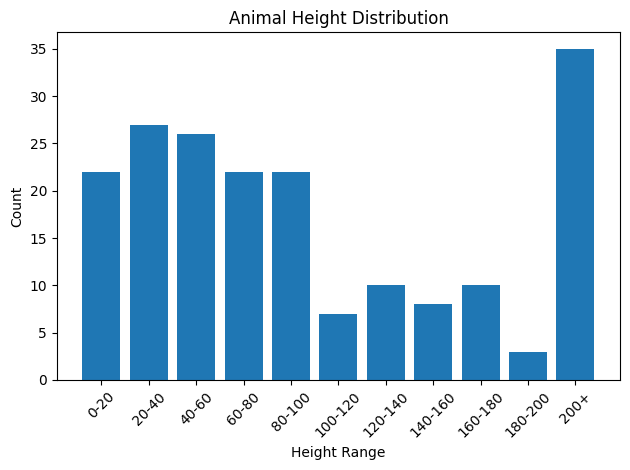

In [37]:
#Plotting by count
plot_bar(height_bin, "Animal Height Distribution", "Height Range", "Count")

#### Pie plotting by count

In [38]:
#Universal pie plotter
def plot_pie(data_dict, title):
    labels = list(data_dict.keys())
    sizes = list(data_dict.values())

    plt.figure()
    plt.pie(sizes, labels=labels, autopct='%1.1f%%')
    plt.title(title)
    plt.show()

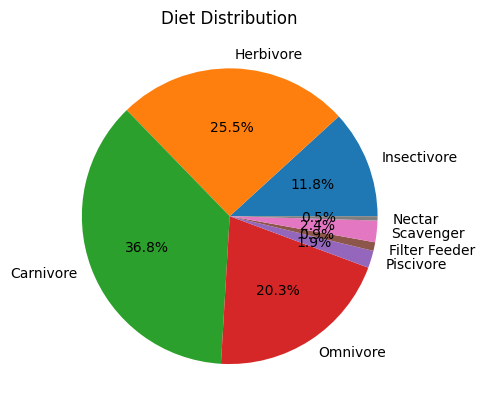

In [39]:
plot_pie(diet_bins, "Diet Distribution")

#### Scatter plot

In [40]:
#Ordering the non-numerical bins

diet_categories = ["Herbivore","Omnivore","Carnivore","Insectivore","Piscivore",
                    "Scavenger","Filter Feeder", "Nectar"]

conservation_status_categories = ["Least Concern","Near Threatened", "Vulnerable",
    "Endangered", "Critically Endangered", "Extinct"
    "Near Threatened", "Not Applicable", "Varies" ]

social_structure_categories = ["Solitary", "Group-based", "Social groups"]



In [53]:
import matplotlib.pyplot as plt
import re

def plot_mixed_scatter(df, col1, col2,
                        diet_categories,
                        conservation_status_categories,
                        social_structure_categories,
                        title=""):

    # ---------- helper: clean numeric ----------
    def clean_value(val):
        if isinstance(val, str):
            val_lower = val.lower()
            if "varies" in val_lower or "not applicable" in val_lower:
                return None
            
            # up to X
            match_up_to = re.match(r"up to (\d+\.?\d*)", val_lower)
            if match_up_to:
                return float(match_up_to.group(1)) / 2
            
            # range X-Y
            match_range = re.match(r"(\d+\.?\d*)\s*-\s*(\d+\.?\d*)", val_lower)
            if match_range:
                return (float(match_range.group(1)) + float(match_range.group(2))) / 2
            
            # single number
            try:
                return float(val)
            except:
                return None
        
        elif isinstance(val, (int, float)):
            return float(val)
        
        return None

    # ---------- define categorical columns ----------
    category_maps = {
        "Diet": diet_categories,
        "Conservation Status": conservation_status_categories,
        "Social Structure": social_structure_categories
    }

    is_cat1 = col1 in category_maps
    is_cat2 = col2 in category_maps

    # ---------- create mappings if categorical ----------
    if is_cat1:
        x_map = {cat: i for i, cat in enumerate(category_maps[col1])}
    if is_cat2:
        y_map = {cat: i for i, cat in enumerate(category_maps[col2])}

    x_vals = []
    y_vals = []

    # ---------- extract + clean ----------
    for v1, v2 in zip(df[col1], df[col2]):

        # handle categorical
        if is_cat1:
            if v1 not in x_map:
                continue
            x_val = x_map[v1]
        else:
            x_val = clean_value(v1)

        if is_cat2:
            if v2 not in y_map:
                continue
            y_val = y_map[v2]
        else:
            y_val = clean_value(v2)

        if x_val is not None and y_val is not None:
            x_vals.append(x_val)
            y_vals.append(y_val)

    # ---------- plotting ----------
    plt.figure(figsize=(8,6))
    plt.scatter(x_vals, y_vals, alpha=0.6)

    # ---------- apply categorical labels ----------
    if is_cat1:
        plt.xticks(range(len(category_maps[col1])), category_maps[col1], rotation=45)
    if is_cat2:
        plt.yticks(range(len(category_maps[col2])), category_maps[col2])

    # ---------- log scale variables ----------
    log_vars = [
        "Weight (kg)",
        "Gestation Period (days)",
        "Height (cm)",
        "Lifespan (years)",
        "Offspring per Birth"
    ]

    if not is_cat1 and col1 in log_vars:
        plt.xscale("log")
    if not is_cat2 and col2 in log_vars:
        plt.yscale("log")

    # ---------- labels ----------
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

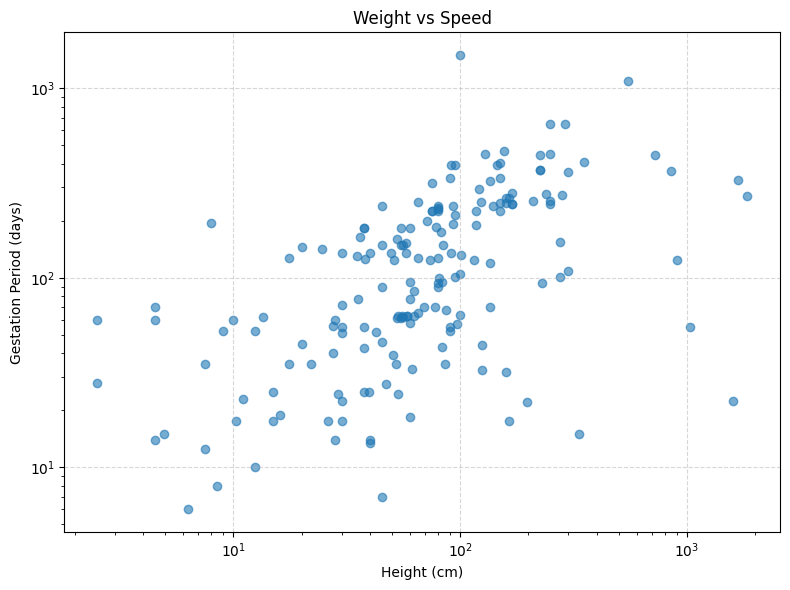

In [54]:
plot_mixed_scatter(df,
                    "Height (cm)",
                    "Gestation Period (days)",
                    diet_categories,
                    conservation_status_categories,
                    social_structure_categories,
                    title="Weight vs Speed")

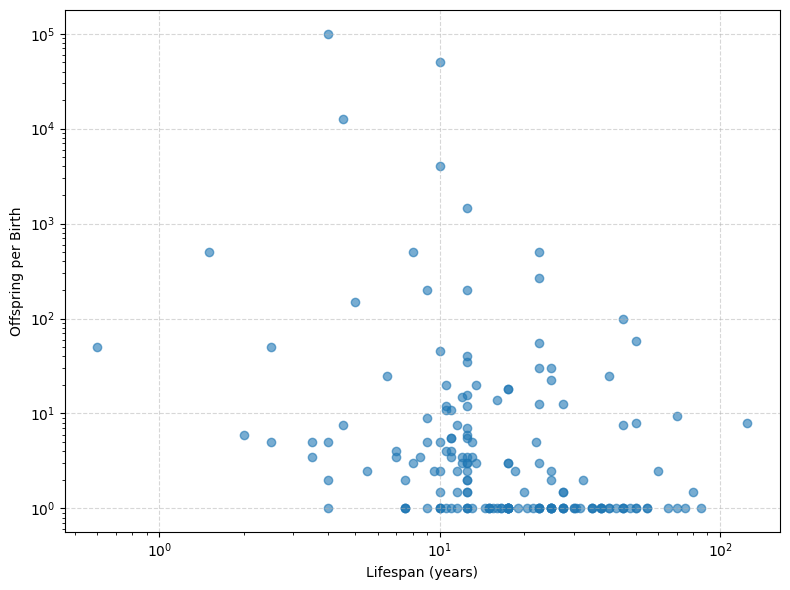

In [94]:
var1 = "Lifespan (years)"
var2 = "Offspring per Birth"

plot_mixed_scatter(df,
                    var1,
                    var2,
                    diet_categories,
                    conservation_status_categories,
                    social_structure_categories,
                    title="")

#### Heatmap

In [153]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# =========================
# PREDEFINED BINS
# =========================
numerical_bins = {
    "height (cm)": height_bin,
    "weight (kg)": weight_bins,
    "lifespan (years)": lifespan_bins,
    "average speed (km/h)": AvgSpeed_bins,
    "top speed (km/h)": topspeed_bins,
    "gestation period (days)": gestation_day_bins,
    "offspring per birth": offspring_per_birth_bins
}

categorical_bins = {
    "diet": diet_categories,
    "conservation status": conservation_status_categories,
    "social structure": social_structure_categories
}

# =========================
# CLEAN NUMERICAL VALUES
# =========================
def clean_value(val):
    if isinstance(val, str):
        val_lower = val.lower()
        if "varies" in val_lower or "not applicable" in val_lower:
            return None
        
        match_up_to = re.match(r"up to (\d+\.?\d*)", val_lower)
        if match_up_to:
            return float(match_up_to.group(1)) / 2
        
        match_range = re.match(r"(\d+\.?\d*)\s*-\s*(\d+\.?\d*)", val_lower)
        if match_range:
            return (float(match_range.group(1)) + float(match_range.group(2))) / 2
        
        try:
            return float(val)
        except:
            return None

    elif isinstance(val, (int, float)):
        return float(val)

    return None


# =========================
# BIN DICT → EDGES
# =========================
def get_bin_edges(bin_dict):
    edges = []

    for key in bin_dict.keys():
        key = key.strip()

        # Case 1: "X-Y"
        if "-" in key:
            try:
                low, high = key.split("-")
                edges.append(float(low))
                edges.append(float(high))
            except:
                continue

        # Case 2: "X+"
        elif "+" in key:
            try:
                edges.append(float(key.replace("+", "")))
            except:
                continue

        # Case 3: single number "X"
        else:
            try:
                val = float(key)
                edges.append(val)
                edges.append(val + 1)  # small range so it forms a bin
            except:
                continue

    edges = sorted(list(set(edges)))

    return edges


# =========================
# MAIN HEATMAP FUNCTION
# =========================
def plot_heatmap2(df, var1, var2, title="Heatmap", cmap="RdYlGn_r", type = ""):

    v1_key = var1.lower()
    v2_key = var2.lower()

    x_bin_dict = numerical_bins.get(v1_key)
    y_bin_dict = numerical_bins.get(v2_key)

    x_is_num = x_bin_dict is not None
    y_is_num = y_bin_dict is not None

    clean_x = []
    clean_y = []

    # =========================
    # CLEAN DATA
    # =========================
    for v1, v2 in zip(df[var1], df[var2]):
        cx = clean_value(v1) if x_is_num else v1
        cy = clean_value(v2) if y_is_num else v2

        if cx is not None and cy is not None:
            clean_x.append(cx)
            clean_y.append(cy)

    # =========================
    # CASE 1: NUM + NUM
    # =========================
    if x_is_num and y_is_num:

        x_edges = get_bin_edges(x_bin_dict)
        y_edges = get_bin_edges(y_bin_dict)

        heatmap, _, _ = np.histogram2d(clean_x, clean_y, bins=[x_edges, y_edges])

        x_labels = list(x_bin_dict.keys())
        y_labels = list(y_bin_dict.keys())

    # =========================
    # CASE 2: CAT + NUM
    # =========================
    elif not x_is_num and y_is_num:

        y_edges = get_bin_edges(y_bin_dict)
        y_labels = list(y_bin_dict.keys())[:len(y_edges)-1]

        x_categories = categorical_bins.get(v1_key, [])

        heatmap = np.zeros((len(y_edges) - 1, len(x_categories)))

        for x, y in zip(clean_x, clean_y):

            # find y bin
            for i in range(len(y_edges) - 1):
                if y_edges[i] <= y < y_edges[i + 1]:
                    row = i
                    break
            else:
                continue

            # split multi-category
            x_parts = [i.strip() for i in str(x).split(",")]

            for xp in x_parts:
                if xp in x_categories:
                    col = x_categories.index(xp)
                    heatmap[row][col] += 1

        x_labels = x_categories

    # =========================
    # CASE 3: NUM + CAT
    # =========================
    elif x_is_num and not y_is_num:

        x_edges = get_bin_edges(x_bin_dict)
        x_labels = list(x_bin_dict.keys())

        y_categories = categorical_bins.get(v2_key, [])

        heatmap = np.zeros((len(y_categories), len(x_edges) - 1))

        for x, y in zip(clean_x, clean_y):

            # find x bin
            for i in range(len(x_edges) - 1):
                if x_edges[i] <= x < x_edges[i + 1]:
                    col = i
                    break
            else:
                continue

            # split multi-category
            y_parts = [i.strip() for i in str(y).split(",")]

            for yp in y_parts:
                if yp in y_categories:
                    row = y_categories.index(yp)
                    heatmap[row][col] += 1

        y_labels = y_categories

    # =========================
    # CASE 4: CAT + CAT
    # =========================
    else:

        x_categories = categorical_bins.get(v1_key, [])
        y_categories = categorical_bins.get(v2_key, [])

        heatmap = np.zeros((len(y_categories), len(x_categories)))

        for x, y in zip(clean_x, clean_y):

            x_parts = [i.strip() for i in str(x).split(",")]
            y_parts = [i.strip() for i in str(y).split(",")]

            for xp in x_parts:
                for yp in y_parts:
                    if xp in x_categories and yp in y_categories:
                        row = y_categories.index(yp)
                        col = x_categories.index(xp)
                        heatmap[row][col] += 1

        x_labels = x_categories
        y_labels = y_categories

    # =========================
    # PLOT
    # =========================
    plt.figure(figsize=(9,6))
    plt.imshow(
            heatmap,
            origin='lower',
            aspect='auto',
            cmap=cmap,
            interpolation= type   
        )
    plt.colorbar(label="Count")

    plt.xticks(np.arange(len(x_labels)), x_labels, rotation=45)
    plt.yticks(np.arange(len(y_labels)), y_labels)

    plt.xlabel(var1)
    plt.ylabel(var2)
    plt.title(title)

    plt.tight_layout()
    plt.show()

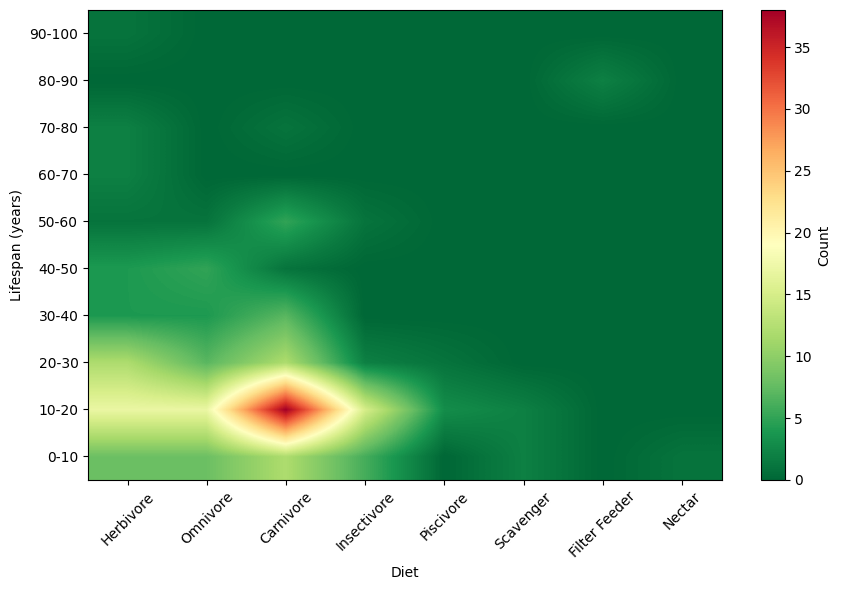

In [155]:
v1 = "Diet"
v2 = "Lifespan (years)"

plot_heatmap2(df,
                v1,
                v2,
                title="", type = "bilinear")    
#type should either be bilinear or nearest or gaussian